In [1]:
# Mount Drive and load processed data
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

OUTPUT_DIR = '/content/drive/MyDrive/insurance_fraud/processed/'
df = pd.read_parquet(OUTPUT_DIR + 'train_provider_merged.parquet')

fraud     = df[df['fraud_label'] == 1]
non_fraud = df[df['fraud_label'] == 0]

print(f'Dataset loaded: {df.shape}')
print(f'Fraud     : {len(fraud):,}  ({len(fraud)/len(df)*100:.1f}%)')
print(f'Non-fraud : {len(non_fraud):,}  ({len(non_fraud)/len(df)*100:.1f}%)')

Mounted at /content/drive
Dataset loaded: (5410, 34)
Fraud     : 506  (9.4%)
Non-fraud : 4,904  (90.6%)


In [2]:
# EDA Summary Statistics
compare_cols = ['ip_claim_count', 'ip_avg_reimbursement', 'ip_avg_stay_days',
                'total_unique_patients', 'ip_avg_chronic_cond', 'ip_unique_attending_phys']

rows = []
for col in [c for c in compare_cols if c in df.columns]:
    rows.append({
        'Feature'         : col,
        'Non-Fraud (mean)': round(non_fraud[col].mean(), 2),
        'Fraud (mean)'    : round(fraud[col].mean(), 2),
        'Ratio F/NF'      : round(fraud[col].mean() / (non_fraud[col].mean() + 1e-9), 2)
    })

print(pd.DataFrame(rows).to_string(index=False))

                 Feature  Non-Fraud (mean)  Fraud (mean)  Ratio F/NF
          ip_claim_count              3.48         46.25       13.29
    ip_avg_reimbursement           3363.58       9605.43        2.86
        ip_avg_stay_days              1.87          5.32        2.85
   total_unique_patients             49.39        247.53        5.01
     ip_avg_chronic_cond              1.85          4.83        2.61
ip_unique_attending_phys              1.58          8.19        5.17


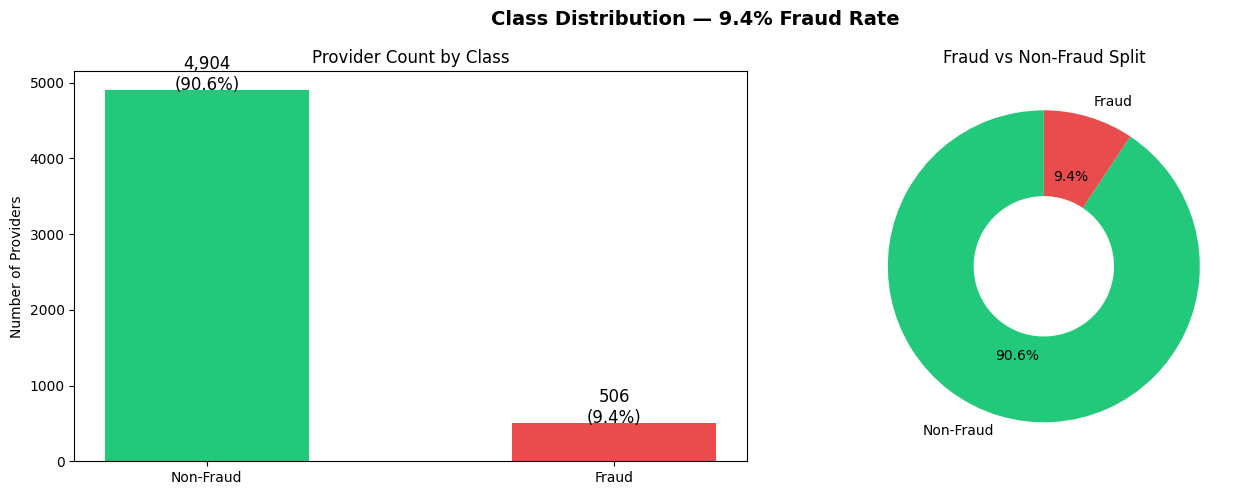

Saved plot1_class_distribution.png


In [3]:
# Plot 1: Class Distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
counts = df['fraud_label'].value_counts().sort_index()

axes[0].bar(['Non-Fraud', 'Fraud'], counts.values, color=['#22C97A', '#E84C4C'], width=0.5)
axes[0].set_title('Provider Count by Class')
axes[0].set_ylabel('Number of Providers')
for bar, val in zip(axes[0].patches, counts.values):
    axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+5,
                 f'{val:,}\n({val/len(df)*100:.1f}%)', ha='center', fontsize=12)

axes[1].pie(counts.values, labels=['Non-Fraud','Fraud'], colors=['#22C97A','#E84C4C'],
            autopct='%1.1f%%', startangle=90, wedgeprops=dict(width=0.55))
axes[1].set_title('Fraud vs Non-Fraud Split')
plt.suptitle('Class Distribution — 9.4% Fraud Rate', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(OUTPUT_DIR.replace('processed/','plots/') + 'plot1_class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved plot1_class_distribution.png')